In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import *
import requests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *
import warnings
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
import torch.optim as optim
import CONSTANTS
from functions import *
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import clone
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from xgboostImplementation import XGBoost
import pickle
warnings.filterwarnings('ignore')

In [24]:
data = pd.read_csv(fullDataPath(COIN))
merged = dataSetup(data)
merged

,close,avg_sentiment,tweet_count,volume,BB_Lower,BB_Middle,BB_Upper,SMA_50,Volume_MA_20,value,value_classification,OBV,gradient
time,,,,,,,,,,,,,
2015-07-20,280.00,0.000000,1,782.883420,268.225216,283.7070,299.188784,257.5800,4944.509312,37.0,Fear,-3.765494e+06,0.00
2015-07-21,277.32,0.000000,1,4943.559434,266.070961,283.0885,300.106039,256.8628,5157.713985,37.0,Fear,-3.766277e+06,-2.68
2015-07-22,277.89,0.000000,1,4687.909383,263.804416,282.4800,301.155584,256.0914,5184.465121,37.0,Fear,-3.761334e+06,0.57
2015-07-23,277.39,0.000000,1,5306.919575,263.024051,282.1850,301.345949,255.3040,5239.876891,37.0,Fear,-3.766022e+06,-0.50
2015-07-24,289.12,0.000000,1,7362.469083,261.412057,281.6625,301.912943,254.5742,5292.043713,37.0,Fear,-3.760715e+06,11.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-20,103317.80,-0.190040,80,5047.437875,100534.750726,105416.8885,110299.026274,105304.8762,0.000000,48.0,Neutral,-8.441932e+03,-1354.10
2025-06-21,102160.03,-2.569288,88,3287.513275,100534.750726,105416.8885,110299.026274,105304.8762,0.000000,43.0,Neutral,-1.348937e+04,-1157.77
2025-06-22,100996.87,3.217055,31,7872.258744,100534.750726,105416.8885,110299.026274,105304.8762,0.000000,40.0,Neutral,-1.677688e+04,-1163.16


# XGBoost Implementation

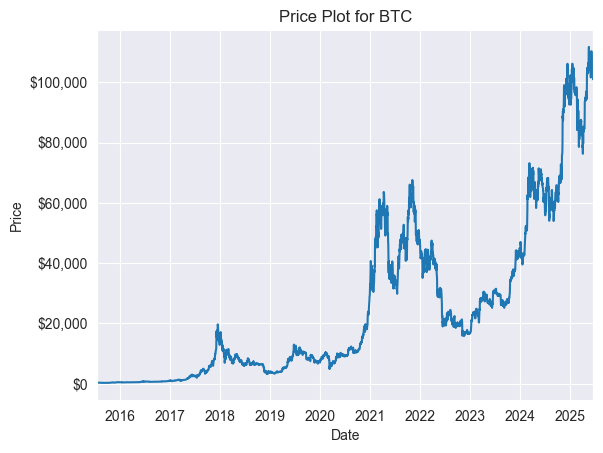

In [29]:
merged['close'].plot.line()
plt.title(f'Price Plot for {COIN}')
plt.xlabel('Date')
plt.ylabel('Price')
# format y axis to show currency
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

In [37]:
trainingCols = [i.strip() for i in open('training_columns.txt', 'r').readlines()]
percentage = 0.8
X = merged[trainingCols]
y = merged['close']
n = len(data)


line = len(merged)-TEST_DAYS

X_train = X.iloc[:line].reset_index(drop=True)
X_test = X.iloc[line:].reset_index(drop=True)
y_train = y.iloc[:line].reset_index(drop=True)
y_test = y.iloc[line:].reset_index(drop=True)

X_train, X_test, y_train, y_test, sequence_scaler, target_scaler = normalize_regular(X_train, X_test, y_train, y_test)
X_train.shape, X_test.shape

((3621, 10), (7, 10))

In [38]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and fit model
xgb_model = XGBoost(
    base_estimator=RandomForestRegressor(n_estimators=50),
    n_estimators=50,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)
items = xgb_model.cross_validate(X_train, y_train, cv=5)

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5


In [39]:
items

{'test_scores': array([0.03248737, 0.03623835, 0.04301531, 0.04129038, 0.03857333]),
 'test_score_mean': 0.03832094495897707,
 'test_score_std': 0.003722529297284819}

In [40]:
items['test_score_mean']/y_train.std()

0.03831565310713122

In [41]:
xgb_model.fit(X_train, y_train)
predictions = xgb_model.predict(X_test)
predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
y_test_rescaled = target_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
predictions

array([105463.69107996, 105015.91143686, 104872.74201655, 103172.23703195,
       102544.95988607, 103895.60454096, 106413.35123394])

In [42]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test_rescaled, predictions, squared=False)

1126.291268581629

<Axes: >

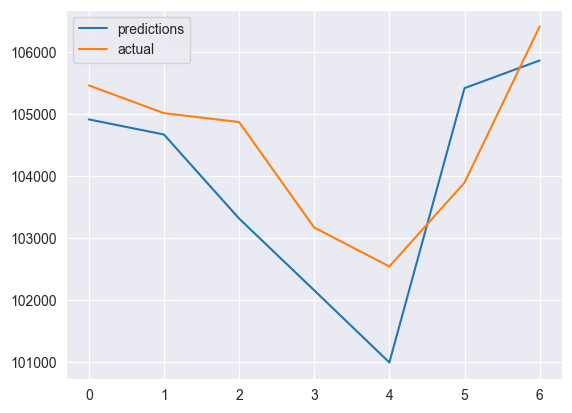

In [43]:
comparison = pd.DataFrame(predictions, y_test_rescaled).reset_index()
comparison.columns = ['predictions', 'actual']
# get latest date from data and add the number of rows in X_test to it
comparison.plot.line()

In [45]:
custom_param_grid = {
        'n_estimators': [30, 50, 100],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 5, 8, 15],
        'subsample': [0.8, 1.0]
    }
xgb_model.tune_hyperparameters(X_train, y_train, param_grid=custom_param_grid, cv=5)

100%|██████████| 72/72 [02:16<00:00,  1.89s/it]


{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 30, 'subsample': 1.0}

<Axes: >

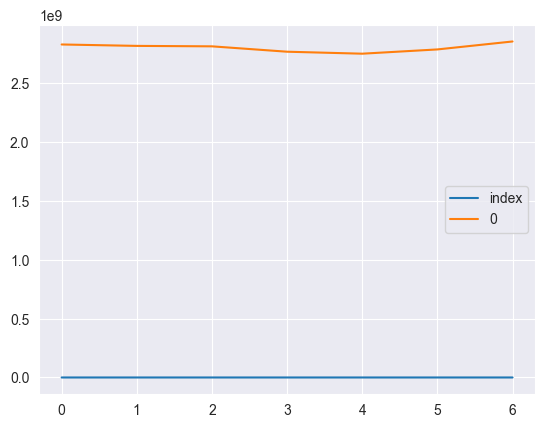

In [46]:
best_model = xgb_model.fit_best(X_train, y_train)
y_pred = best_model.predict(X_test)
predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
y_test_rescaled = target_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
comparison = pd.DataFrame(predictions, y_test_rescaled).reset_index()
comparison.plot.line()

In [47]:
comparison.to_csv('plots/XGB_best_comparison.csv', index=False)
best_model.save('models/xgb_best_model.pkl')